# Exploratory Analysis of Satellite Orbital Characteristics

This notebook explores publicly available satellite orbital element data from Celestrak.  
The dataset contains orbital parameters derived from Two-Line Element (TLE) records maintained by NORAD. These parameters describe the geometry and motion of satellites orbiting Earth.

**Data source**  
Celestrak Active Satellite Element Sets (retrieved March 2026)  
https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv

The dataset contains orbital parameters for thousands of satellites, including:

- mean motion
- eccentricity
- inclination
- right ascension of the ascending node
- argument of perigee
- mean anomaly

These parameters describe the orientation, shape, and motion of each satellite orbit.

The goal of this analysis is to examine patterns in satellite orbital characteristics, identify common orbital regimes, and detect unusual orbital behavior.

## Orbital Parameters Used in This Analysis

Several orbital parameters are used throughout the analysis:

**Mean Motion**  
The number of complete revolutions a satellite makes around Earth per day. Higher values generally indicate lower altitude orbits.

**Inclination**  
The tilt of a satellite's orbit relative to Earth's equator, measured in degrees.  
0° represents an equatorial orbit, while 90° represents a polar orbit.

**Eccentricity**  
A measure of how circular or elongated an orbit is.  
Values near 0 represent nearly circular orbits, while larger values indicate more elliptical trajectories.

**Orbital Period**  
The time required for a satellite to complete one orbit around Earth.  
This value can be derived from mean motion.

## Load and Inspect the Dataset

The dataset contains orbital element parameters for thousands of satellites. These parameters describe the orientation, shape, and motion of each orbit. Before performing any analysis, the structure and basic statistical properties of the dataset are examined.

In [2]:
# Load the satellite orbital element dataset from Celestrak
# This dataset contains Two Line Element (TLE) parameters describing
# satellite orbits around Earth.

import pandas as pd

df = pd.read_csv("NORAD_elements.csv")

# Display the first few records to understand the structure
print(df.head())

# View column names
print(df.columns)

# Generate descriptive statistics for numeric variables
# This helps identify ranges and potential anomalies in the data.
print(df.describe())

    OBJECT_NAME  OBJECT_ID                       EPOCH  MEAN_MOTION  \
0   CALSPHERE 1  1964-063C  2026-03-08T10:34:35.438016    13.764962   
1   CALSPHERE 2  1964-063E  2026-03-08T12:47:48.688224    13.528916   
2         LCS 1  1965-034C  2026-03-08T14:20:55.815936     9.893100   
3     TEMPSAT 1  1965-065E  2026-03-08T08:58:27.428448    13.335891   
4  CALSPHERE 4A  1965-065H  2026-03-08T14:33:00.185760    13.362590   

   ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  ARG_OF_PERICENTER  MEAN_ANOMALY  \
0      0.002366      90.2159         69.4217           234.8519      292.9984   
1      0.001938      90.2282         73.4078           154.1355      331.0336   
2      0.001318      32.1434         55.8520           126.0868      234.0852   
3      0.007011      89.9935        212.5870           170.3510      256.9351   
4      0.007034      89.9034        123.4814            29.2484      124.8578   

   EPHEMERIS_TYPE CLASSIFICATION_TYPE  NORAD_CAT_ID  ELEMENT_SET_NO  \
0              

## Deriving Orbital Period

Mean motion represents the number of revolutions a satellite completes per day.  
From this value we can derive the orbital period using:

**orbital_period_minutes = 1440 / mean_motion**

In [4]:
# Convert mean motion into orbital period.
# Mean motion represents revolutions per day.
# Orbital period can therefore be calculated as:

# orbital_period_minutes = minutes per day / revolutions per day

df["orbital_period_minutes"] = 1440 / df["MEAN_MOTION"]

# Summarize the distribution of orbital periods
print(df["orbital_period_minutes"].describe())

count    14661.000000
mean       161.789013
std        331.337886
min         87.612586
25%         94.105860
50%         94.580168
75%         96.104356
max      19685.744431
Name: orbital_period_minutes, dtype: float64


## Classifying Orbit Regimes

Satellites can be grouped into orbital regimes based on their orbital period or mean motion.  
For exploratory analysis, a simple rule-based classification is used:

- **LEO (Low Earth Orbit):** high mean motion
- **MEO (Medium Earth Orbit):** moderate mean motion
- **High Orbit:** slower orbital velocities

In [5]:
# Perform a simple classification of orbit types based on mean motion.
# This gives a rough separation of orbital regimes.

df["orbit_type"] = pd.cut(
    df["MEAN_MOTION"],
    bins=[0,2,10,20],
    labels=["High Orbit","Medium Orbit","Low Orbit"]
)

# Count satellites in each orbit category
print(df["orbit_type"].value_counts())

orbit_type
Low Orbit       13856
High Orbit        681
Medium Orbit      124
Name: count, dtype: int64


In [6]:
# Define a function to classify orbit regimes using a rule-based approach.

def orbit_category(row):

    if row["MEAN_MOTION"] > 11:
        return "LEO"       # Low Earth Orbit
    elif row["MEAN_MOTION"] > 1.5:
        return "MEO"       # Medium Earth Orbit
    else:
        return "High Orbit"

# Apply the classification function to each satellite
df["orbit_class"] = df.apply(orbit_category, axis=1)

# View the number of satellites in each orbit class
print(df["orbit_class"].value_counts())

orbit_class
LEO           13856
High Orbit      610
MEO             195
Name: count, dtype: int64


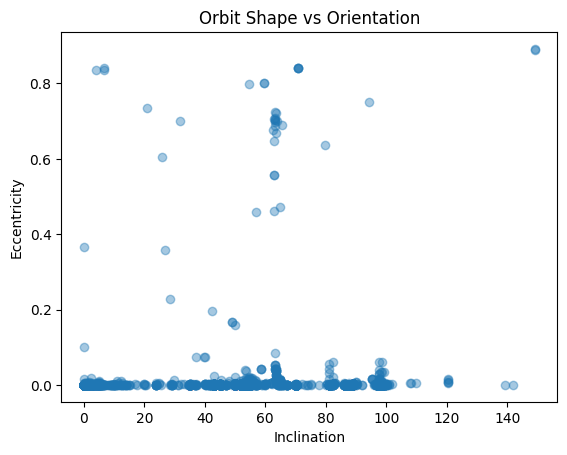

In [7]:
# Examine the relationship between inclination and eccentricity.
# Eccentricity describes how circular or elliptical the orbit is.

plt.scatter(df["INCLINATION"], df["ECCENTRICITY"], alpha=0.4)

plt.xlabel("Inclination")
plt.ylabel("Eccentricity")
plt.title("Orbit Shape vs Orientation")

plt.show()

In [8]:
# Identify satellites with unusually high orbital eccentricity.
# Most operational satellites have nearly circular orbits.

outliers = df[df["ECCENTRICITY"] > 0.1]

# Display key parameters for these satellites
print(outliers[["OBJECT_NAME","ECCENTRICITY","INCLINATION","MEAN_MOTION"]])

                   OBJECT_NAME  ECCENTRICITY  INCLINATION  MEAN_MOTION
15            PHASE 3B (AO-10)      0.604901      25.9320     2.058741
40                       POLAR      0.636780      79.7489     1.298458
64                         CXO      0.799440      54.5228     0.378032
69                  XMM-NEWTON      0.470959      64.9804     0.501317
72                       IMAGE      0.750965      94.1397     1.686655
77      CLUSTER II-FM7 (SAMBA)      0.891595     149.0813     0.448361
78      CLUSTER II-FM8 (TANGO)      0.889005     149.0711     0.444060
202                   THEMIS A      0.840370       6.8064     0.878467
204                   THEMIS D      0.835691       6.6532     0.878359
205                   THEMIS E      0.836064       4.1865     0.878375
424                   TACSAT 4      0.462797      62.8170     6.150698
485                EXPRESS-MD2      0.159944      49.8414    12.365194
692       GSAT0201 (GALILEO 5)      0.165755      48.9889     1.855200
693   

## Relationship Between Inclination and Orbital Velocity

This scatter plot provides an initial view of how satellite orbital inclination relates to orbital velocity (mean motion). Each point represents a satellite.

Mean motion indicates how many times a satellite completes an orbit around Earth per day, while inclination represents the tilt of the orbit relative to Earth's equator. Patterns in this plot can reveal clusters corresponding to different orbital regimes.

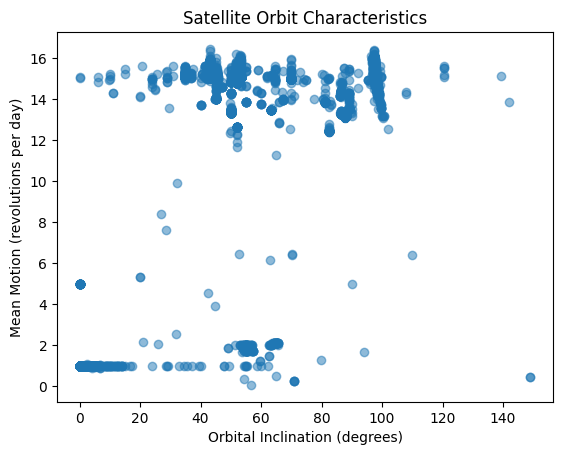

In [20]:
# Visualize the relationship between orbital inclination and mean motion.
# Mean motion indicates how many times a satellite orbits Earth per day.
# Inclination represents the tilt of the orbit relative to Earth's equator.

import matplotlib.pyplot as plt

plt.scatter(df["INCLINATION"], df["MEAN_MOTION"], alpha=0.5)

plt.xlabel("Orbital Inclination (degrees)")
plt.ylabel("Mean Motion (revolutions per day)")
plt.title("Satellite Orbit Characteristics")

plt.show()

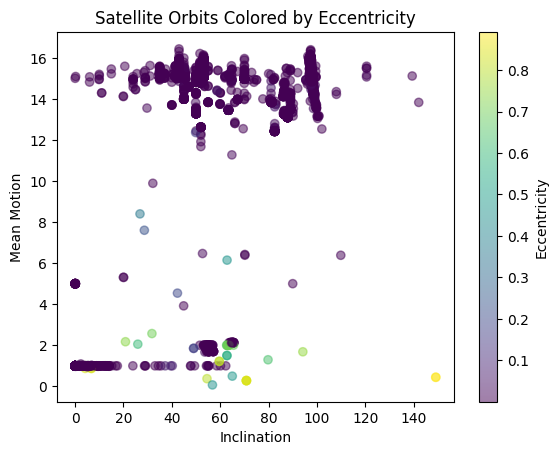

In [ ]:
# ------------------------------------------------------------
# Inclination vs Mean Motion
#
# This scatter plot shows how orbital inclination relates to
# satellite orbital velocity (mean motion). Each point
# represents a satellite.
#
# Points are colored by orbital eccentricity, which highlights
# how circular or elliptical the orbit is. Most satellites
# appear in nearly circular LEO orbits, while highly elliptical
# orbits appear as brighter points.
# ------------------------------------------------------------
# Scatter plot of inclination vs mean motion
# Color represents orbital eccentricity
plt.scatter(
    df["INCLINATION"],
    df["MEAN_MOTION"],
    c=df["ECCENTRICITY"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("Inclination")
plt.ylabel("Mean Motion")
plt.title("Satellite Orbits Colored by Eccentricity")

plt.colorbar(label="Eccentricity")

plt.show()

## Distribution of Orbital Parameters

The following visualizations examine how satellites are distributed across key orbital parameters.  
Histograms help reveal dominant orbit types and identify unusual or extreme orbital configurations.

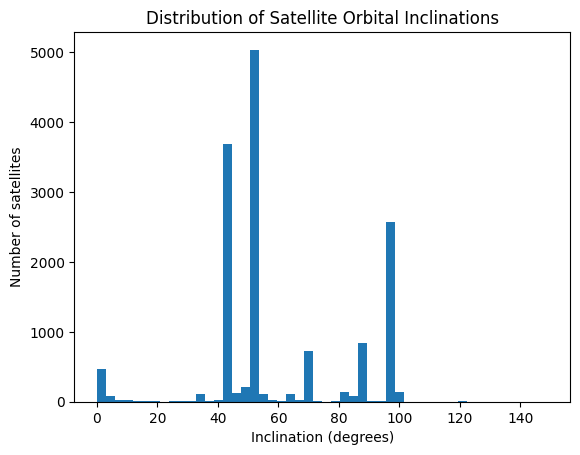

In [10]:
# Visualize the distribution of orbital inclinations.
# This reveals common orbital corridors used by satellite constellations.

plt.hist(df["INCLINATION"], bins=50)

plt.xlabel("Inclination (degrees)")
plt.ylabel("Number of satellites")
plt.title("Distribution of Satellite Orbital Inclinations")

plt.show()

**Observations**

- Satellites appear across a wide range of orbital inclinations.
- Many satellites cluster around common operational inclinations used for communication, navigation, and Earth observation missions.
- Higher inclinations allow satellites to pass over more of the Earth's surface, while lower inclinations focus coverage near the equator.

## Orbit Regime Distribution

Finally, satellites are grouped into orbit regimes to summarize the population distribution across Low Earth Orbit, Medium Earth Orbit, and higher-altitude orbits.

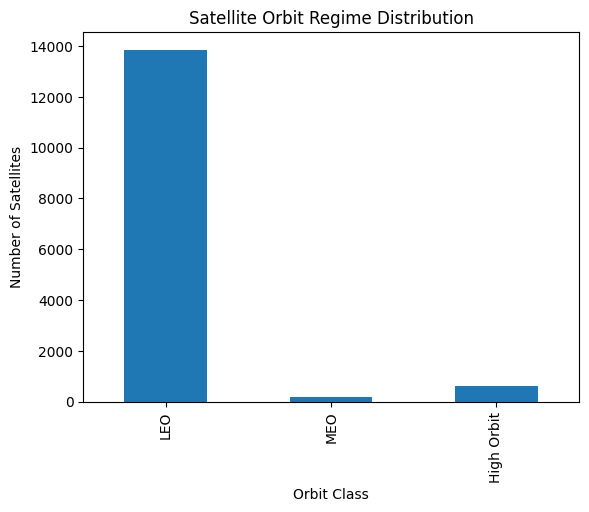

In [18]:
# ------------------------------------------------------------
# Satellite Orbit Regime Distribution
#
# This chart shows the number of satellites in each orbital regime
# using a simple rule-based classification derived from mean motion.
#
# LEO (Low Earth Orbit): satellites that complete many revolutions per day
# MEO (Medium Earth Orbit): moderate orbital periods
# High Orbit: long-period or highly elliptical orbits
#
# The visualization helps illustrate how strongly the satellite
# population is concentrated in LEO compared with other regimes.
# ------------------------------------------------------------
# # Visualize the number of satellites in each orbital regime.
# The orbit_class variable was created earlier using a rule-based
# classification based on mean motion. This plot shows the relative
# population of Low Earth Orbit (LEO), Medium Earth Orbit (MEO),
# and higher-altitude orbits.

# Count satellites in each orbit class and reorder them
# so the chart reads from low to high orbit.
orbit_counts = df["orbit_class"].value_counts().reindex(["LEO","MEO","High Orbit"])

orbit_counts.plot(kind="bar")

plt.title("Satellite Orbit Regime Distribution")
plt.xlabel("Orbit Class")
plt.ylabel("Number of Satellites")

plt.show()

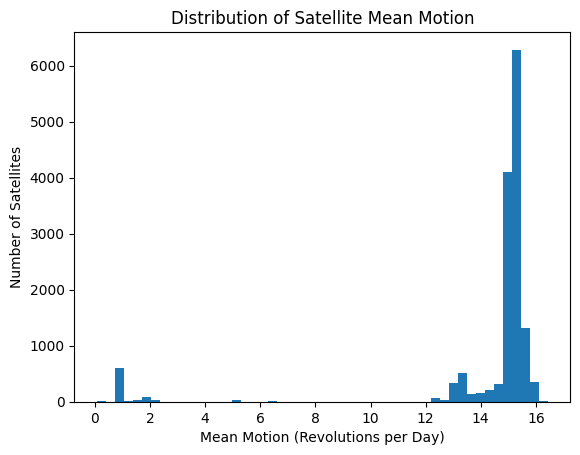

In [ ]:
# ------------------------------------------------------------
# Distribution of Satellite Mean Motion
#
# Mean motion represents the number of orbital revolutions a
# satellite completes per day.
#
# This histogram shows how satellites cluster into distinct
# orbital regimes. LEO satellites appear at higher mean motion
# values (around 14–16 revolutions per day), while satellites
# in higher orbits have much lower values.
#
# The distribution highlights the dominance of LEO satellites
# in the current active satellite population.
# ------------------------------------------------------------
# # Plot the distribution of mean motion values.
# Mean motion represents the number of orbital revolutions per day.
# This visualization helps reveal clusters of satellites operating
# in different orbital regimes.

plt.hist(df["MEAN_MOTION"], bins=50)

plt.xlabel("Mean Motion (Revolutions per Day)")
plt.ylabel("Number of Satellites")
plt.title("Distribution of Satellite Mean Motion")

plt.show()

**Observations**

- A large concentration of satellites appears around 14–16 revolutions per day.
- This range corresponds to satellites in Low Earth Orbit (LEO).
- Smaller clusters at lower mean motion values represent satellites in higher altitude orbits.

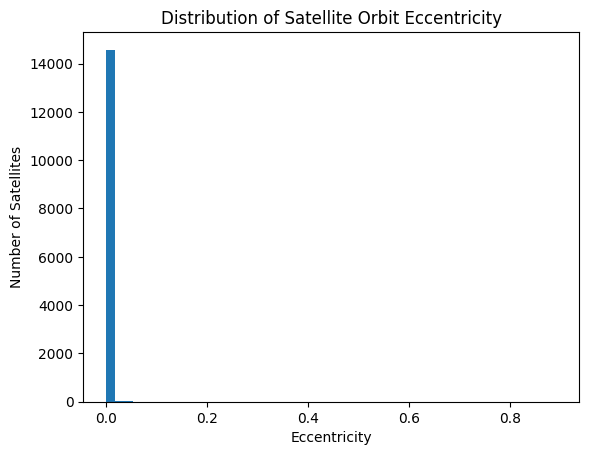

In [ ]:
# ------------------------------------------------------------
# Distribution of Satellite Orbit Eccentricity
#
# Eccentricity measures how circular or elliptical an orbit is.
#
# Values near 0 represent nearly circular orbits, which are
# typical for operational satellites in LEO. Higher values
# indicate increasingly elliptical orbits.
#
# This visualization shows that the majority of active satellites
# operate in nearly circular orbits, with only a small number
# occupying highly elliptical trajectories.
# ------------------------------------------------------------
# # Visualize the distribution of orbital eccentricity.
# Eccentricity describes how circular or elliptical an orbit is.
# Most operational satellites maintain nearly circular orbits,
# so the distribution is expected to be heavily concentrated near zero.

plt.hist(df["ECCENTRICITY"], bins=50)

plt.xlabel("Eccentricity")
plt.ylabel("Number of Satellites")
plt.title("Distribution of Satellite Orbit Eccentricity")

plt.show()

**Observations**

- Most satellites have eccentricity values very close to zero.
- This indicates that the majority of operational satellites use nearly circular orbits.
- Only a small number of satellites have higher eccentricity values, representing more elliptical orbits.

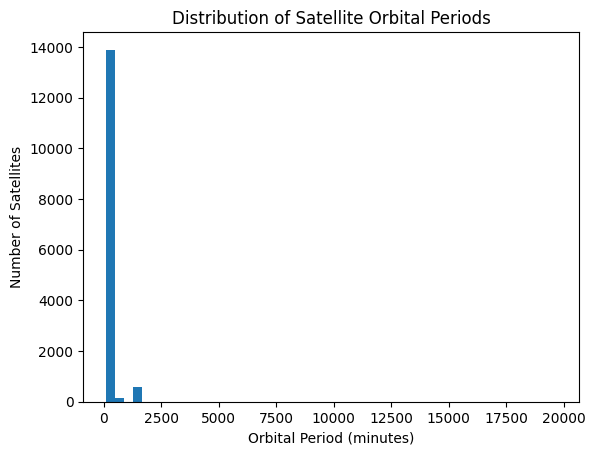

In [ ]:
# ------------------------------------------------------------
# Distribution of Satellite Orbital Periods
#
# Orbital period represents the time required for a satellite
# to complete one full orbit around Earth.
#
# It is derived from mean motion using:
# orbital_period_minutes = 1440 / mean_motion
#
# This histogram illustrates how most satellites have short
# orbital periods typical of LEO, while a smaller number
# occupy much longer-period orbits.
# ------------------------------------------------------------
# # Plot the distribution of orbital periods derived earlier.
# Orbital period was calculated using mean motion:
# orbital_period_minutes = 1440 / mean_motion
# This visualization shows the typical duration of satellite orbits.

plt.hist(df["orbital_period_minutes"], bins=50)

plt.xlabel("Orbital Period (minutes)")
plt.ylabel("Number of Satellites")
plt.title("Distribution of Satellite Orbital Periods")

plt.show()

**Observations**

- Most satellites have relatively short orbital periods.
- This reflects the large number of satellites operating in Low Earth Orbit (LEO), where satellites complete an orbit in roughly 90 minutes.
- A smaller number of satellites have much longer orbital periods, corresponding to higher altitude or highly elliptical orbits.

## Key Observations

Several clear patterns appear in the orbital data:

- Most active satellites operate in Low Earth Orbit (LEO), completing roughly 14–16 revolutions per day.
- The majority of satellites have very low eccentricity, indicating nearly circular orbits.
- A small number of satellites occupy highly elliptical orbits, which appear as higher eccentricity values in the scatter plot.
- Distinct clusters in the inclination vs mean motion plot correspond to different orbital regimes.

These patterns reflect how satellite missions are designed for communication, navigation, Earth observation, and scientific research.